Resume Dataset:
  Candidate_Name                                             Resume
0          Rahul  Python Machine Learning Data Science SQL Deep ...
1          Priya       Java Spring Boot MySQL Backend Developer API
2           Aman  React Node JavaScript HTML CSS Frontend Developer
3          Sneha       Python NLP Machine Learning AI Data Analysis

Job Description:

Python developer with Machine Learning,
NLP, Data Science and AI skills


TF-IDF Vectorization Completed!

Similarity Scores:
[[0.44826799 0.06584472 0.06584472 0.57027739]]

Top Matching Candidates:
  Candidate_Name                                             Resume  \
3          Sneha       Python NLP Machine Learning AI Data Analysis   
0          Rahul  Python Machine Learning Data Science SQL Deep ...   
1          Priya       Java Spring Boot MySQL Backend Developer API   
2           Aman  React Node JavaScript HTML CSS Frontend Developer   

   Similarity_Score  
3         57.027739  
0         44.826799  
1  

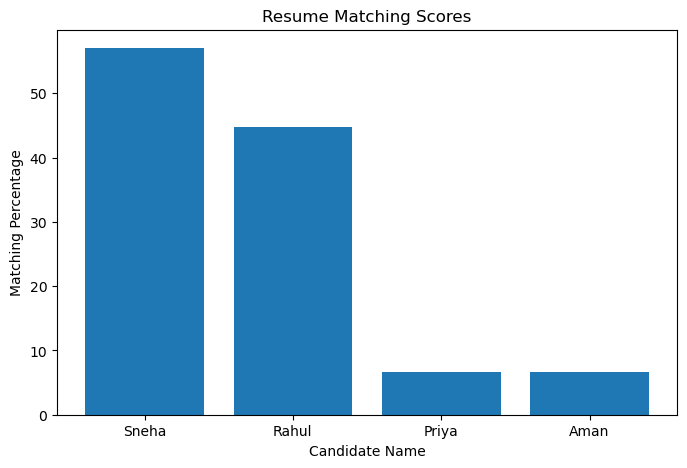

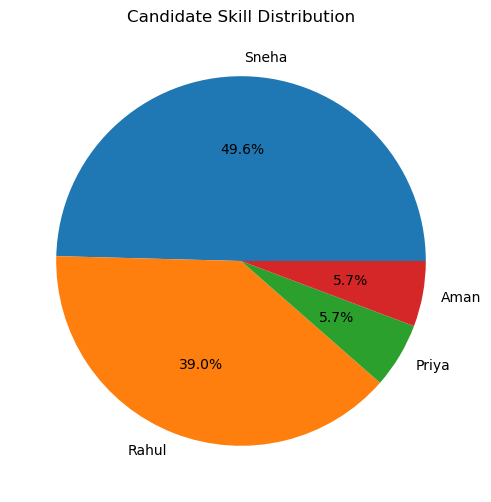


Best Candidate Selected:
Sneha

Matching Score:
57.03 %


In [2]:
# ====================================================
# AI RESUME SCREENING SYSTEM
# ====================================================

# -------------------------------
# STEP 1 : Import Libraries
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NLP Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Similarity Calculation
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# STEP 2 : Create Sample Resumes
# -------------------------------

# Resume data manually create kar rahe hain

data = {
    'Candidate_Name': [
        'Rahul',
        'Priya',
        'Aman',
        'Sneha'
    ],

    'Resume': [

        'Python Machine Learning Data Science SQL Deep Learning',

        'Java Spring Boot MySQL Backend Developer API',

        'React Node JavaScript HTML CSS Frontend Developer',

        'Python NLP Machine Learning AI Data Analysis'
    ]
}

# DataFrame create
df = pd.DataFrame(data)

print("Resume Dataset:")
print(df)

# -------------------------------
# STEP 3 : Job Description
# -------------------------------

job_description = """
Python developer with Machine Learning,
NLP, Data Science and AI skills
"""

print("\nJob Description:")
print(job_description)

# -------------------------------
# STEP 4 : Combine Resume + JD
# -------------------------------

# Resume list
resumes = df['Resume'].tolist()

# Job description add
all_text = resumes + [job_description]

# -------------------------------
# STEP 5 : TF-IDF Vectorization
# -------------------------------

# Text ko numerical vectors me convert karenge

vectorizer = TfidfVectorizer()

vectors = vectorizer.fit_transform(all_text)

print("\nTF-IDF Vectorization Completed!")

# -------------------------------
# STEP 6 : Similarity Calculation
# -------------------------------

# Last vector = Job Description
# Remaining = resumes

similarity = cosine_similarity(
    vectors[-1],
    vectors[:-1]
)

print("\nSimilarity Scores:")
print(similarity)

# -------------------------------
# STEP 7 : Add Scores to Dataset
# -------------------------------

df['Similarity_Score'] = similarity[0]

# Percentage convert
df['Similarity_Score'] = (
    df['Similarity_Score'] * 100
)

# -------------------------------
# STEP 8 : Sort Best Candidates
# -------------------------------

df = df.sort_values(
    by='Similarity_Score',
    ascending=False
)

print("\nTop Matching Candidates:")
print(df)

# ====================================================
# DATA VISUALIZATION
# ====================================================

# -------------------------------
# GRAPH 1 : Candidate Matching Score
# -------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    df['Candidate_Name'],
    df['Similarity_Score']
)

plt.title("Resume Matching Scores")

plt.xlabel("Candidate Name")
plt.ylabel("Matching Percentage")

plt.show()

# -------------------------------
# GRAPH 2 : Pie Chart
# -------------------------------

plt.figure(figsize=(6,6))

plt.pie(
    df['Similarity_Score'],
    labels=df['Candidate_Name'],
    autopct='%1.1f%%'
)

plt.title("Candidate Skill Distribution")

plt.show()

# ====================================================
# STEP 9 : Best Candidate
# ====================================================

best_candidate = df.iloc[0]

print("\nBest Candidate Selected:")
print(best_candidate['Candidate_Name'])

print("\nMatching Score:")
print(round(best_candidate['Similarity_Score'],2), "%")

# ====================================================
# PROJECT COMPLETED
# ====================================================